<a href="https://colab.research.google.com/github/Hologram-guy/CFD_ML_Rocket/blob/main/Architecture_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # %cd     /content/drive/MyDrive/Colab Notebooks/Rocket_CFD_ML
    # ! pip install -q transformers==4.57.2 accelerate datasets trl bitsandbytes

Mounted at /content/drive


In [2]:
import os
import re
import math
import pandas as pd
import torch

# from datasets import Dataset, concatenate_datasets, load_dataset, load_from_disk
# from trl import SFTTrainer, SFTConfig
# from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#MAKE SURE YOU ARE USING GPU
print('Using device:', device)

Using device: cuda


In [3]:
#other imports
import json
import random
from torch.utils.data import DataLoader, Dataset, TensorDataset
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

In [4]:
#GLOBAL CONFIG
seed = 42

In [5]:
#loading geometry Data
def geometry_extract_to_dict(data, field_names : list, target_key="id"):
    results = {}

    if isinstance(data, dict):
        # If the key exists, use its VALUE as the key for our results dict
        if target_key in data:
            key_value = data[target_key]
            results[key_value] = {k: data[k] for k in field_names if k in data}

        # Recurse into the values
        for value in data.values():
            results.update(geometry_extract_to_dict(value, field_names, target_key))

    elif isinstance(data, list):
        for item in data:
            results.update(geometry_extract_to_dict(item, field_names, target_key))

    return results

def coefficient_extract_to_dict(data, field_names: list, target_key="id"):
    results = {}
    for entry in data:
        if isinstance(entry, dict) and target_key in entry:
            key_value = entry[target_key]
            # Extract from the 'entry', not the 'data' list
            results[key_value] = {k: entry[k] for k in field_names if k in entry}
    return results


In [6]:
def train_test_split_dict(ml_data, random_state=42, train_test_split_ratio=0.8):
    # 1. Get and shuffle the keys
    random.seed(random_state)
    random.shuffle(ml_data)

    # 2. Determine split index
    split_idx = int(len(ml_data) * train_test_split_ratio)
    ml_train = ml_data[:split_idx]
    ml_test = ml_data[split_idx:]

    return ml_train, ml_test

In [7]:
# #loading data
# geometry_input_file = '/content/drive/MyDrive/Colab Notebooks/Rocket_CFD_ML/Data/Potential_2/simulation_plan.json'
# coefficient_input_file = '/content/drive/MyDrive/Colab Notebooks/Rocket_CFD_ML/Data/Potential_2/results_full.json'

# #releant felds
# geometry_input_fields = ["id", "L", "H", "R", "fin_root", "fin_tip", "fin_height", "thickness"]
# coefficient_input_fields = ["id", "DragForce"]

# #aerodynamic data
# with open(coefficient_input_file, 'r') as f:
#   coefficient_data_raw = json.load(f)

# coefficient_data = coefficient_extract_to_dict(coefficient_data_raw, coefficient_input_fields, target_key="id")

# #geometry input file formatting and data
# with open(geometry_input_file, 'r') as f:
#   geometry_data_raw = json.load(f)

# geometry_data = geometry_extract_to_dict(geometry_data_raw, geometry_input_fields, target_key="id")


#generating training and test splits for the geometry and coefficient
ml_input = '/content/drive/MyDrive/Colab Notebooks/Rocket_CFD_ML/Data/Potential_2/ml_dataset.json'

with open(ml_input, 'r') as f:
  ml_data = json.load(f)
ml_train, ml_test =  train_test_split_dict(ml_data, random_state = seed)




In [8]:
class CoefficientDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
            entry = self.data[idx]

            # 1. Prepare Geometry Tensors
            body_geom = torch.tensor([entry['L'], entry['R']], dtype=torch.float32)
            nose_geom = torch.tensor([entry['H'], entry['R']], dtype=torch.float32)
            fin_geom = torch.tensor([entry['fin_root'], entry['fin_tip'],
                                    entry['fin_height'], entry['thickness']], dtype=torch.float32)

            # 2. Prepare CD Tensors (Ensuring they are 2D for the MLP: [1])
            body_cd = torch.tensor([entry["body_DragForce"]], dtype=torch.float32)
            nose_cd = torch.tensor([entry["nose_DragForce"]], dtype=torch.float32)
            fin_cd = torch.tensor([entry["fin_DragForce"]], dtype=torch.float32)

            # 3. Prepare Position Tensors
            body_pos = torch.tensor([entry["body_r_min"], entry["body_z_min"]], dtype=torch.float32)
            nose_pos = torch.tensor([entry["nose_r_min"], entry["nose_z_min"]], dtype=torch.float32)
            fin_pos = torch.tensor([entry["fin_r_min"], entry["fin_z_min"]], dtype=torch.float32)

            # 4. The Target (Y)
            label = torch.tensor([entry['composite_DragForce']], dtype=torch.float32)

            # Return a tuple of everything
            return body_geom, body_cd, nose_geom, nose_cd, fin_geom, fin_cd, body_pos, nose_pos, fin_pos, label

In [9]:
def min_max_scale(val, v_min, v_max):
    """Standard Min-Max Normalization: scales values to [0, 1]"""
    if v_max == v_min:
        return 0.0
    return (val - v_min) / (v_max - v_min)

def normalize_dataset(data_list, keys_to_normalize, norm_func=min_max_scale):
    """
    data_list: [ {key1: val, key2: val}, {key1: val, ...} ]
    keys_to_normalize: list of strings
    norm_func: the function used to scale the numbers
    """
    # 1. FIND GLOBAL MIN/MAX FOR EACH KEY
    stats = {k: {'min': float('inf'), 'max': float('-inf')} for k in keys_to_normalize}

    # Iterate directly through the list
    for entry in data_list:
        for k in keys_to_normalize:
            if k in entry:
                val = entry[k]
                if val < stats[k]['min']: stats[k]['min'] = val
                if val > stats[k]['max']: stats[k]['max'] = val

    # 2. APPLY NORMALIZATION
    normalized_list = []

    for entry in data_list:
        # Create a shallow copy to avoid modifying the original list in memory
        new_entry = entry.copy()
        for k in keys_to_normalize:
            if k in entry:
                v_min = stats[k]['min']
                v_max = stats[k]['max']
                new_entry[k] = norm_func(entry[k], v_min, v_max)
        normalized_list.append(new_entry)

    return normalized_list, stats

# --- EXAMPLE USAGE ---
# normalized_data, geometry_stats = normalize_dataset(raw_list, ["L", "R", "H"])

In [10]:
#normalizing datasets
geometry_list = ["L", "H", "R", "fin_root", "fin_tip", "fin_height", "thickness"]
drag_list = ["composite_DragForce", "body_DragForce", "nose_DragForce", "fin_DragForce"]
position_list = ["body_r_min", "body_z_min", "nose_r_min", "nose_z_min", "fin_r_min", "fin_z_min"]

norm_list = geometry_list + drag_list + position_list
# Unpack both the dictionary and the stats (don't forget the second variable!)
ml_train_norm, ml_train_norm_dict = normalize_dataset(ml_train, norm_list)
ml_test_norm, ml_test_norm_dicts = normalize_dataset(ml_test, norm_list)

# Now these variables are DICTS again, and the Dataset will work.
train_dataset = CoefficientDataset(ml_train_norm)
test_dataset = CoefficientDataset(ml_test_norm)

#defining loaders
train_dataloader = DataLoader(train_dataset, batch_size=32,shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32,shuffle=True)

ml_train_norm[0]


{'id': 'comp_0870',
 'body_id': 'body_r5_l12',
 'nose_id': 'nose_r5_h13',
 'fin_id': 'fin_165',
 'L': 0.16657085369358995,
 'H': 0.25561139028475705,
 'R': 0.8772826880934989,
 'fin_root': 0.3901156677181915,
 'fin_tip': 0.2090862157976252,
 'fin_height': 0.3205837946653246,
 'thickness': 0.37499999999999994,
 'body_r_min': 0.0,
 'body_r_max': 1.799,
 'body_z_min': 0.0,
 'body_z_max': 9.197,
 'nose_r_min': 0.0,
 'nose_r_max': 1.799,
 'nose_z_min': 0.16657085369358995,
 'nose_z_max': 11.965,
 'fin_r_min': 0.8772826880934989,
 'fin_r_max': 3.437,
 'fin_z_min': 0.0,
 'fin_z_max': 2.249,
 'composite_Cd': -0.2755658,
 'composite_DragForce': 0.5352529656258703,
 'body_Cd': 0.5645282,
 'body_DragForce': 0.7696957072953876,
 'nose_Cd': 0.539608,
 'nose_DragForce': 0.49582073795763826,
 'fin_Cd': -0.0004038628,
 'fin_DragForce': 0.30415157869405973}

In [11]:
class DynamicMLP(nn.Module):
    def __init__(self, layer_list, activation = nn.SiLU()):
        super().__init__()
        self.layers = nn.ModuleList()

        for i in range(len(layer_list)-1):
          self.layers.append(nn.Linear(layer_list[i], layer_list[i+1]))

          if i < len(layer_list) - 2:
            self.layers.append(activation)

    def forward(self, x):

        for layer in self.layers:
          x = layer(x)

        return x

In [12]:
class CompositeRocket(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Use self. to ensure these are registered as model parameters
        self.body_encoder = DynamicMLP([3, latent_dim//2, latent_dim, latent_dim])
        self.nose_encoder = DynamicMLP([3, latent_dim//2, latent_dim, latent_dim])
        self.fin_encoder = DynamicMLP([5, latent_dim, latent_dim*2, latent_dim*2, latent_dim])

        self.positional_encoder = DynamicMLP([2, latent_dim//2, latent_dim, latent_dim])

        # Input to aggregator is latent_dim * 3 (Nose + Body + Fins)
        self.aggregator = DynamicMLP([latent_dim * 3, latent_dim, latent_dim*2, latent_dim*4,
                                      latent_dim*4, latent_dim*2, latent_dim, latent_dim//2, 1])

    def forward(self, body_geom, body_cd, nose_geom, nose_cd, fin_geom, fin_cd, body_pos, nose_pos, fin_pos):
        # 1. Prepare inputs
        body_input = torch.cat([body_geom, body_cd], dim=1)
        nose_input = torch.cat([nose_geom, nose_cd], dim=1)
        fin_input = torch.cat([fin_geom, fin_cd], dim=1)

        # 2. Encode Geometry (Removed the extra latent_dim argument)
        body_lat = self.body_encoder(body_input)
        nose_lat = self.nose_encoder(nose_input)
        fin_lat = self.fin_encoder(fin_input)

        # 3. Add Positional Encoding
        body_lat = body_lat + self.positional_encoder(body_pos)
        nose_lat = nose_lat + self.positional_encoder(nose_pos)
        fin_lat = fin_lat + self.positional_encoder(fin_pos)

        # 4. Concatenate along the feature dimension (dim=1)
        combined_latent = torch.cat([body_lat, nose_lat, fin_lat], dim=1)

        # 5. Calculate interference
        sum_drag = body_cd + nose_cd + fin_cd
        interference_correction = self.aggregator(combined_latent) # Renamed from self.inference

        return sum_drag + interference_correction

In [13]:
# # 1. Create an iterator
# data_iter = iter(train_dataloader)

# # 2. Grab the first batch
# # The * operator puts the first 9 tensors into a list called 'all_inputs'
# # and the very last tensor into 'label'
# *all_inputs, label = next(data_iter)

# print("Success! First batch received.")
# print(f"Number of input tensors: {len(all_inputs)}")
# print(f"Shape of first input (body_geom): {all_inputs[0].shape}")
# print(f"Shape of label (total_drag): {label.shape}")

In [14]:
def train(
    model, optimizer, criterion, num_epochs, train_dataloader, test_dataloader=None,
    scheduler=None  # <--- ADDED: Allow passing a scheduler
):
    model.to(device)
    train_losses = []
    test_losses = []
    epoch_pbar = tqdm(range(num_epochs), desc="Training Progress")

    for epoch in epoch_pbar:
        # === TRAINING PHASE ===
        model.train()
        running_train_loss = 0.0
        for batch in train_dataloader:
            *inputs, label = batch
            inputs = [i.to(device, dtype=torch.float32) for i in inputs]
            label = label.to(device, dtype=torch.float32)

            optimizer.zero_grad()
            y_hat = model(*inputs)
            loss = criterion(y_hat, label)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        # === TEST PHASE ===
        avg_test_loss = 0.0
        if test_dataloader:
            model.eval()
            running_test_loss = 0.0
            with torch.no_grad():
                for batch in test_dataloader:
                    *inputs, label = batch
                    inputs = [i.to(device, dtype=torch.float32) for i in inputs]
                    label = label.to(device, dtype=torch.float32)
                    y_hat = model(*inputs)
                    loss = criterion(y_hat, label)
                    running_test_loss += loss.item()

            avg_test_loss = running_test_loss / len(test_dataloader)
            test_losses.append(avg_test_loss)

            # === SCHEDULER STEP ===
            # We step here so the scheduler can look at the test loss
            if scheduler is not None:
                scheduler.step(avg_test_loss)  # <--- ADDED

        epoch_pbar.set_postfix({
            "train_loss": f"{avg_train_loss:.6f}",
            "test_loss": f"{avg_test_loss:.6f}"
        })

    return train_losses, test_losses

In [15]:
# 1. Instantiate the Aggregator model
# Ensure the model class name matches what you defined (e.g., CompositeRocket or Aggregator)
compositeRocket_model = CompositeRocket(latent_dim=32)

# 2. Set the number of epochs (increased for better convergence)
num_epochs = 100

# 3. Set the optimizer
optimizer = torch.optim.Adam(
    compositeRocket_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5  # Start small (1e-5 or 1e-4)
)
# 4. Set the loss criterion (Corrected name)
# criterion = torch.nn.HuberLoss(delta=0.1) #revert back to MSE....
criterion = torch.nn.MSELoss() #revert back to MSE....

# 5. Add the Scheduler
# 'min' means it waits for the loss to stop decreasing
# 'patience=5' means wait 5 epochs of no improvement before cutting the rate
# 'factor=0.5' means cut the learning rate in half
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 6. Call your train function as normal
# (You will need to pass the scheduler into the function)
train_losses, test_losses = train(
    compositeRocket_model,
    optimizer,
    criterion,
    num_epochs,
    train_dataloader,
    test_dataloader,
    scheduler=scheduler  # <--- Pass it in here
)

Training Progress: 100%|██████████| 100/100 [00:52<00:00,  1.90it/s, train_loss=0.002890, test_loss=0.003560]


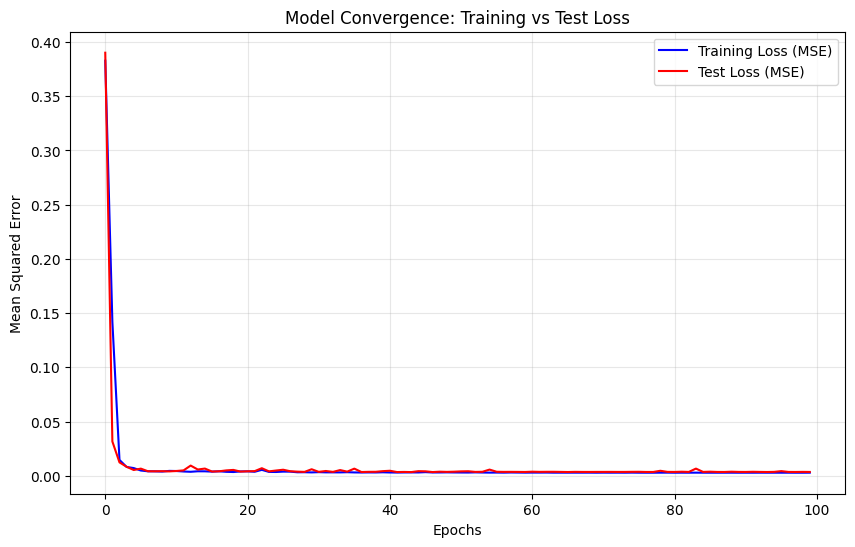

[0.3901378095149994, 0.03164150044322014, 0.012366361853977045, 0.008344851589451233, 0.005352466019879406, 0.006619939060571293, 0.004198345491507401, 0.0041559233761897, 0.004265246846868346, 0.00407227324321866, 0.004447661526501179, 0.00499495780095458, 0.009430111292749644, 0.005809057069321473, 0.0066694476796935005, 0.0039350908560057485, 0.004157867554264764, 0.004988402252395948, 0.005429969169199467, 0.003904289954031507, 0.004154191085126513, 0.004321089247241616, 0.007014134122679631, 0.00408904190796117, 0.0048765779860938585, 0.005603359236071507, 0.004207070327053467, 0.0038493406483515475, 0.0036150541234140593, 0.00604728472729524, 0.0036466257724290093, 0.004444253091545155, 0.0036183358480532963, 0.005283858844389518, 0.0038494188765374323, 0.006617880294409891, 0.0034951819805428387, 0.0036717470735311507, 0.003701188403647393, 0.004295982606709004, 0.004657597560435533, 0.0034658151290689904, 0.0035746040540592123, 0.0034306525602005424, 0.004274691812073191, 0.004

In [16]:
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss (MSE)', color='blue')
    plt.plot(test_losses, label='Test Loss (MSE)', color='red')

    plt.title('Model Convergence: Training vs Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Usage:
plot_losses(train_losses, test_losses)
print(test_losses)

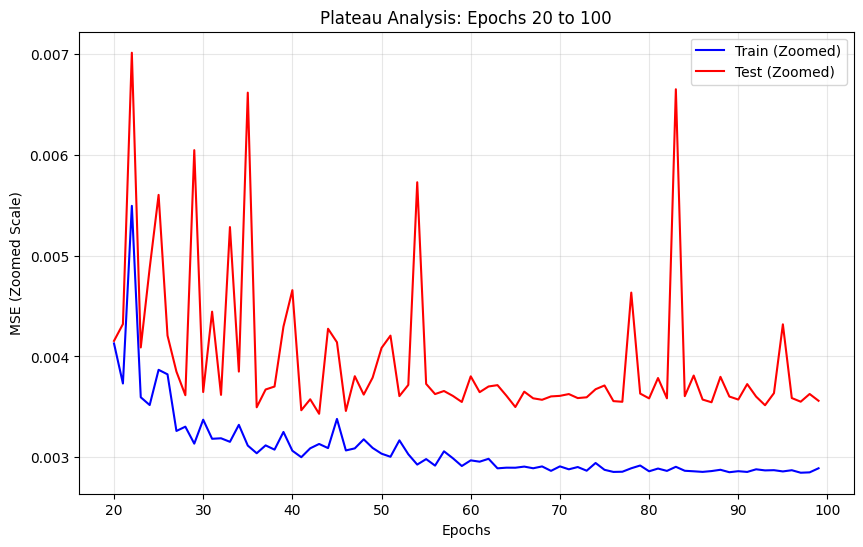

In [17]:
def plot_plateau(train_losses, test_losses, start_epoch=20):
    plt.figure(figsize=(10, 6))

    # Slice the lists to only show the plateau
    epochs = range(start_epoch, len(train_losses))
    plt.plot(epochs, train_losses[start_epoch:], label='Train (Zoomed)', color='blue')
    plt.plot(epochs, test_losses[start_epoch:], label='Test (Zoomed)', color='red')

    plt.title(f'Plateau Analysis: Epochs {start_epoch} to {len(train_losses)}')
    plt.xlabel('Epochs')
    plt.ylabel('MSE (Zoomed Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Call this to see the subtle improvements
plot_plateau(train_losses, test_losses)

In [18]:
def inspect_random_prediction(model, test_dataset, device):
    model.eval()
    # Pick a random index from the test set
    idx = random.randint(0, len(test_dataset) - 1)

    # Get the data (this returns the 10 tensors from your __getitem__)
    *inputs, label = test_dataset[idx]

    # Add batch dimension and move to device: [Features] -> [1, Features]
    inputs_batched = [i.unsqueeze(0).to(device) for i in inputs]

    with torch.no_grad():
        prediction = model(*inputs_batched)

    # Move back to CPU for printing
    prediction = prediction.item()
    actual = label.item()

    # Calculate the simple "Sum of Parts" for comparison
    # indices: 1=body_cd, 3=nose_cd, 5=fin_cd
    sum_of_parts = inputs[1].item() + inputs[3].item() + inputs[5].item()
    interference = prediction - sum_of_parts

    print(f"--- Inspection for Test Case Index: {idx} ---")
    print(f"Input Features (Normalized):")
    print(f"  Nose (H, R):         {inputs[2].tolist()}")
    print(f"  Body (L, R):         {inputs[0].tolist()}")
    print(f"  Fins (root, tip...): {inputs[4].tolist()}")
    print(f"  Fin Position (r, z): {inputs[8].tolist()}")
    print("-" * 30)
    print(f"Sum of Individual Cds: {sum_of_parts:.6f}")
    print(f"Model Total Prediction: {prediction:.6f}")
    print(f"Actual CFD Result:      {actual:.6f}")
    print(f"Learned Interference:   {interference:.6f}")
    print(f"Error:                  {abs(prediction - actual):.6f}")

# Usage:
inspect_random_prediction(compositeRocket_model, test_dataset, device)

--- Inspection for Test Case Index: 422 ---
Input Features (Normalized):
  Nose (H, R):         [0.9865996837615967, 0.04090576991438866]
  Body (L, R):         [0.7483472228050232, 0.04090576991438866]
  Fins (root, tip...): [0.6309148073196411, 0.6623644828796387, 0.8293910622596741, 0.5972222089767456]
  Fin Position (r, z): [0.04090576991438866, 0.0]
------------------------------
Sum of Individual Cds: 0.536620
Model Total Prediction: 0.909834
Actual CFD Result:      0.907198
Learned Interference:   0.373214
Error:                  0.002636


--- Final Evaluation Summary ---
R-squared Score: 0.9078 (90.78% of variance explained)
Mean Absolute Error (Normalized): 0.045529


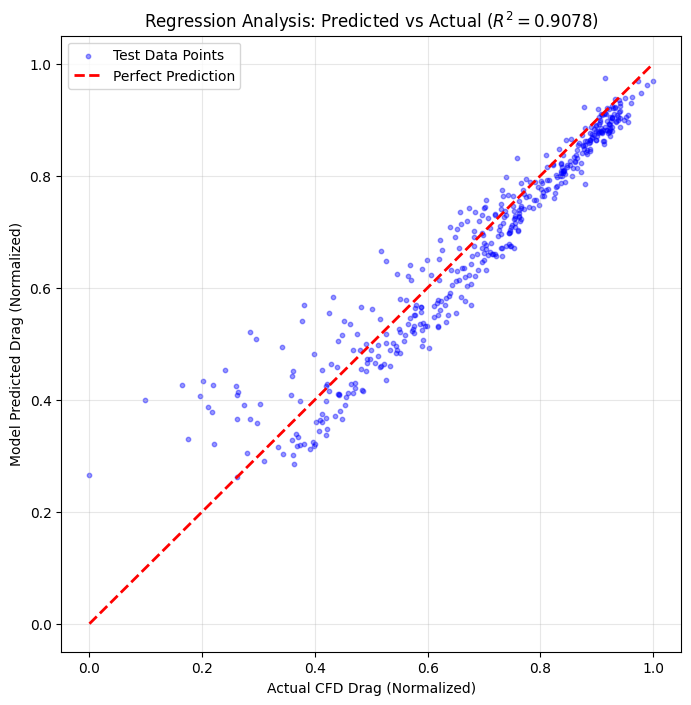

In [19]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model_performance(model, dataloader, device):
    model.eval()
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for batch in dataloader:
            # 1. Unpack and move to device
            *inputs, label = batch
            inputs = [i.to(device, dtype=torch.float32) for i in inputs]

            # 2. Forward pass
            y_hat = model(*inputs)

            # 3. Store results for calculation
            all_preds.append(y_hat.cpu().numpy())
            all_actuals.append(label.cpu().numpy())

    # Flatten the lists into single arrays
    y_pred = np.concatenate(all_preds).ravel()
    y_true = np.concatenate(all_actuals).ravel()

    # Calculate R2 Score
    r2 = r2_score(y_true, y_pred)

    # Calculate Mean Absolute Error (MAE) for physical context
    mae = np.mean(np.abs(y_true - y_pred))

    print(f"--- Final Evaluation Summary ---")
    print(f"R-squared Score: {r2:.4f} ({(r2*100):.2f}% of variance explained)")
    print(f"Mean Absolute Error (Normalized): {mae:.6f}")

    # Plot Predicted vs Actual
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.4, color='blue', s=10, label='Test Data Points')

    # Add a perfect 45-degree reference line
    line_min, line_max = y_true.min(), y_true.max()
    plt.plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Perfect Prediction')

    plt.xlabel('Actual CFD Drag (Normalized)')
    plt.ylabel('Model Predicted Drag (Normalized)')
    plt.title(f'Regression Analysis: Predicted vs Actual ($R^2 = {r2:.4f}$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return r2, mae

# Run the final evaluation
r2_val, mae_val = evaluate_model_performance(compositeRocket_model, test_dataloader, device)

In [20]:
# Define the save path (Colab-specific path shown here)
model_save_path = '/content/drive/MyDrive/Colab Notebooks/Rocket_CFD_ML/Coefficient_Predictor/compositeRocket_v1_baseline.pth'

# Ensure the directory exists
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the model weights
torch.save(compositeRocket_model.state_dict(), model_save_path)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: /content/drive/MyDrive/Colab Notebooks/Rocket_CFD_ML/Coefficient_Predictor/compositeRocket_v1_baseline.pth
